<a href="https://www.kaggle.com/code/lalit7881/e-commerce-order-risk-classification-eda?scriptVersionId=322350426" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/emirhanakku/e-commerce-order-risk-classification-dataset/synthetic_ecommerce_order_risk_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/emirhanakku/e-commerce-order-risk-classification-dataset/synthetic_ecommerce_order_risk_dataset.csv")

In [3]:
df.head()

,order_id,order_date,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,...,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud,risk_label
0,ORD-2024-001936,2024-01-03,Belgium,Mobile,Paid Ads,Credit Card,Sports,381,3,28.66,...,105.7,5,0,0,0,0,4.4,0,0,Normal
1,ORD-2025-006495,2025-11-26,Netherlands,Desktop,Email,Debit Card,Garden,561,6,41.93,...,528.2,4,0,0,0,0,4.8,0,0,Normal
2,ORD-2023-001721,2023-11-07,Netherlands,Mobile,Organic Search,Debit Card,Garden,324,2,102.67,...,175.1,5,0,0,0,0,3.3,0,0,Normal
3,ORD-2024-009121,2024-05-28,Netherlands,Mobile,Organic Search,Klarna,Electronics,378,3,72.71,...,271.4,3,0,0,0,0,4.2,1,0,Return Risk
4,ORD-2025-000361,2025-01-31,Netherlands,Desktop,Direct,Bank Transfer,Home & Kitchen,447,5,52.26,...,285.3,3,0,1,0,0,5.0,0,0,Normal


In [4]:
df.tail()

,order_id,order_date,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,...,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud,risk_label
11995,ORD-2023-011965,2023-02-19,France,Mobile,Social Media,Credit Card,Garden,742,3,25.75,...,121.4,3,0,0,0,1,4.5,0,0,Normal
11996,ORD-2023-005192,2023-05-12,France,Mobile,Organic Search,Debit Card,Fashion,152,1,96.29,...,225.5,4,0,0,0,0,5.0,0,0,Normal
11997,ORD-2024-005391,2024-06-13,Germany,Mobile,Organic Search,Credit Card,Fashion,130,0,114.14,...,669.6,5,0,0,0,0,4.5,0,0,Normal
11998,ORD-2025-000861,2025-04-04,Poland,Desktop,Marketplace,PayPal,Fashion,203,1,21.60,...,229.4,5,0,0,0,0,4.4,0,0,Normal
11999,ORD-2024-007271,2024-05-23,Netherlands,Desktop,Organic Search,PayPal,Beauty,288,2,35.58,...,406.6,3,0,0,0,1,3.7,0,0,Normal


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   order_id                   12000 non-null  object 
 1   order_date                 12000 non-null  object 
 2   country                    12000 non-null  object 
 3   device_type                12000 non-null  object 
 4   traffic_source             12000 non-null  object 
 5   payment_method             12000 non-null  object 
 6   product_category           12000 non-null  object 
 7   customer_age_days          12000 non-null  int64  
 8   previous_orders            12000 non-null  int64  
 9   avg_order_value_eur        12000 non-null  float64
 10  order_value_eur            12000 non-null  float64
 11  quantity                   12000 non-null  int64  
 12  discount_rate              12000 non-null  float64
 13  shipping_distance_km       12000 non-null  flo

In [6]:
df.describe()

,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,discount_rate,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,352.789083,1.943417,48.940278,61.053339,2.171833,0.146857,479.196567,4.058917,0.060000,0.048583,0.044167,0.200667,4.412433,0.092667,0.037250
std,237.556088,1.902590,28.716864,55.540429,1.625534,0.113934,330.305205,1.105312,0.237497,0.215004,0.205474,0.478803,0.545286,0.289977,0.189382
min,5.000000,0.000000,8.000000,5.000000,1.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.300000,0.000000,0.000000
25%,177.000000,1.000000,29.070000,26.617500,1.000000,0.060000,236.100000,3.000000,0.000000,0.000000,0.000000,0.000000,4.100000,0.000000,0.000000
50%,299.000000,1.000000,42.100000,45.335000,2.000000,0.120000,404.450000,4.000000,0.000000,0.000000,0.000000,0.000000,4.500000,0.000000,0.000000
75%,475.000000,3.000000,61.010000,75.952500,3.000000,0.210000,645.225000,5.000000,0.000000,0.000000,0.000000,0.000000,4.900000,0.000000,0.000000
max,1832.000000,13.000000,350.450000,810.750000,8.000000,0.750000,2589.700000,9.000000,1.000000,1.000000,1.000000,5.000000,5.000000,1.000000,1.000000


In [7]:
df.isnull().sum()

order_id                     0
order_date                   0
country                      0
device_type                  0
traffic_source               0
payment_method               0
product_category             0
customer_age_days            0
previous_orders              0
avg_order_value_eur          0
order_value_eur              0
quantity                     0
discount_rate                0
shipping_distance_km         0
delivery_days_estimated      0
late_delivery_risk           0
address_mismatch             0
high_risk_ip                 0
customer_support_contacts    0
review_score                 0
is_returned                  0
is_fraud                     0
risk_label                   0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

order_id                      object
order_date                    object
country                       object
device_type                   object
traffic_source                object
payment_method                object
product_category              object
customer_age_days              int64
previous_orders                int64
avg_order_value_eur          float64
order_value_eur              float64
quantity                       int64
discount_rate                float64
shipping_distance_km         float64
delivery_days_estimated        int64
late_delivery_risk             int64
address_mismatch               int64
high_risk_ip                   int64
customer_support_contacts      int64
review_score                 float64
is_returned                    int64
is_fraud                       int64
risk_label                    object
dtype: object

In [10]:
df.shape

(12000, 23)

In [11]:
df.columns

Index(['order_id', 'order_date', 'country', 'device_type', 'traffic_source',
       'payment_method', 'product_category', 'customer_age_days',
       'previous_orders', 'avg_order_value_eur', 'order_value_eur', 'quantity',
       'discount_rate', 'shipping_distance_km', 'delivery_days_estimated',
       'late_delivery_risk', 'address_mismatch', 'high_risk_ip',
       'customer_support_contacts', 'review_score', 'is_returned', 'is_fraud',
       'risk_label'],
      dtype='object')

In [12]:
df.nunique()

order_id                     12000
order_date                    1096
country                          8
device_type                      3
traffic_source                   6
payment_method                   6
product_category                 8
customer_age_days             1131
previous_orders                 14
avg_order_value_eur           6467
order_value_eur               7517
quantity                         8
discount_rate                   73
shipping_distance_km          7086
delivery_days_estimated          9
late_delivery_risk               2
address_mismatch                 2
high_risk_ip                     2
customer_support_contacts        6
review_score                    36
is_returned                      2
is_fraud                         2
risk_label                       3
dtype: int64

## EDA

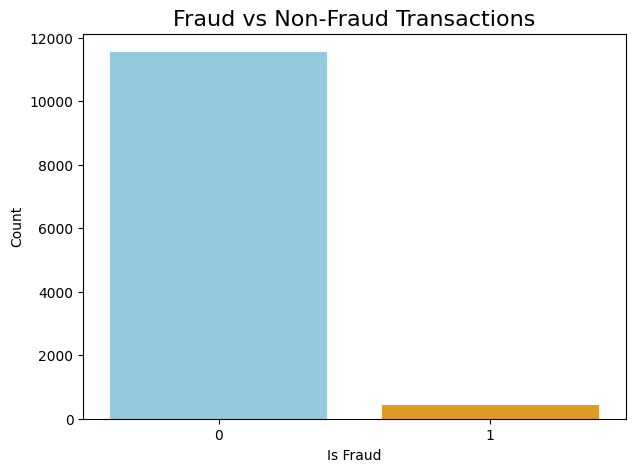

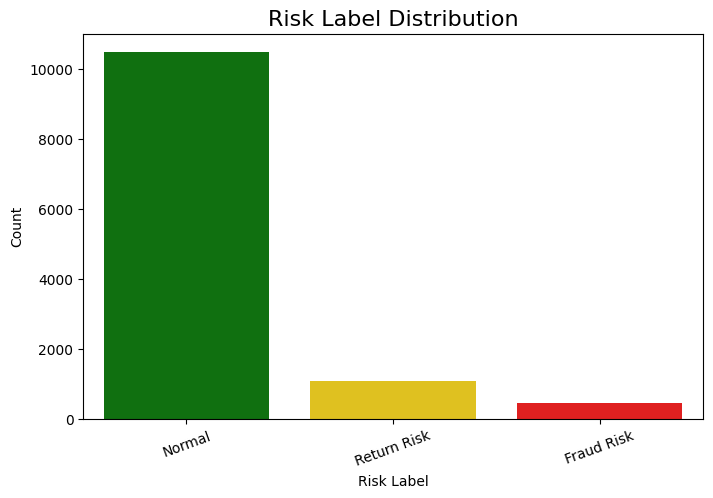

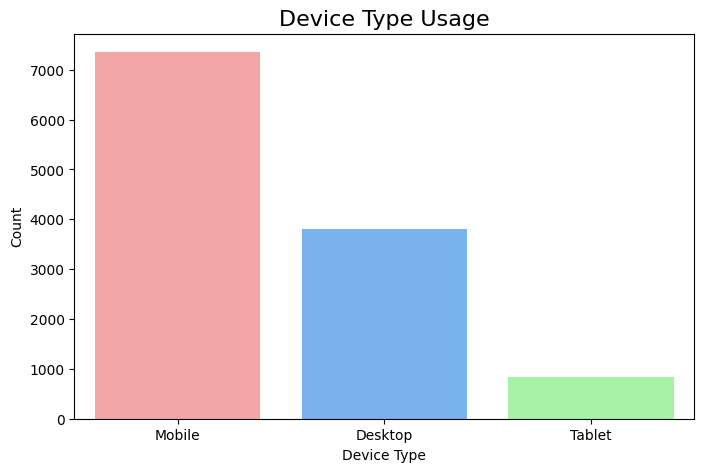

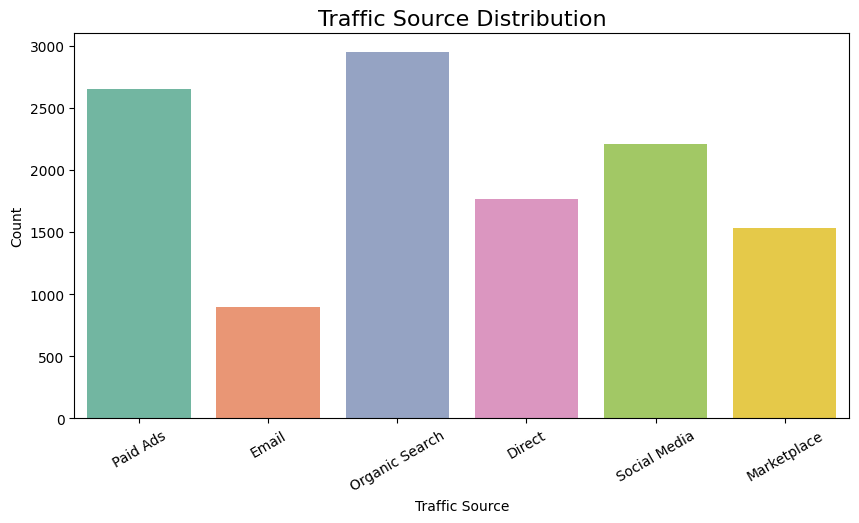

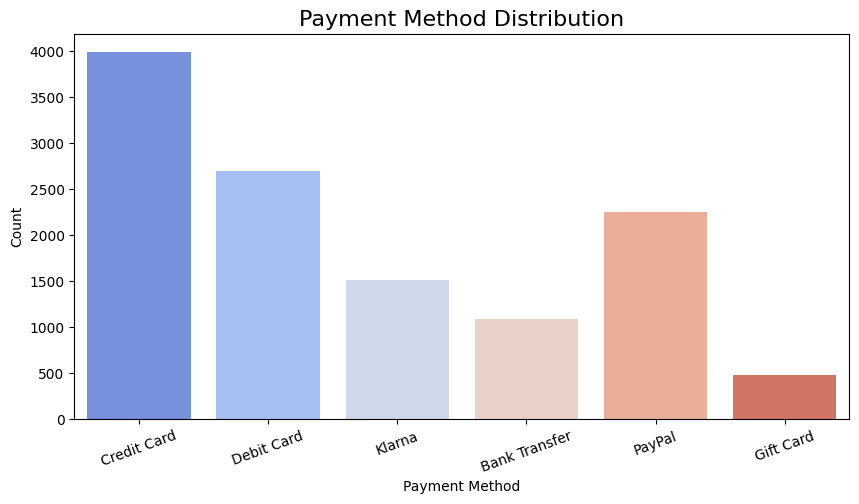

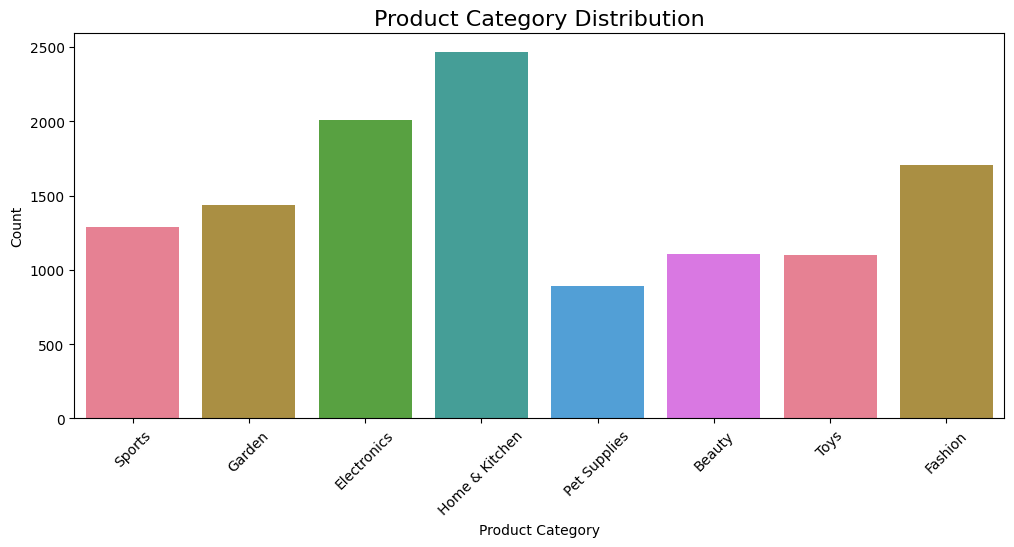

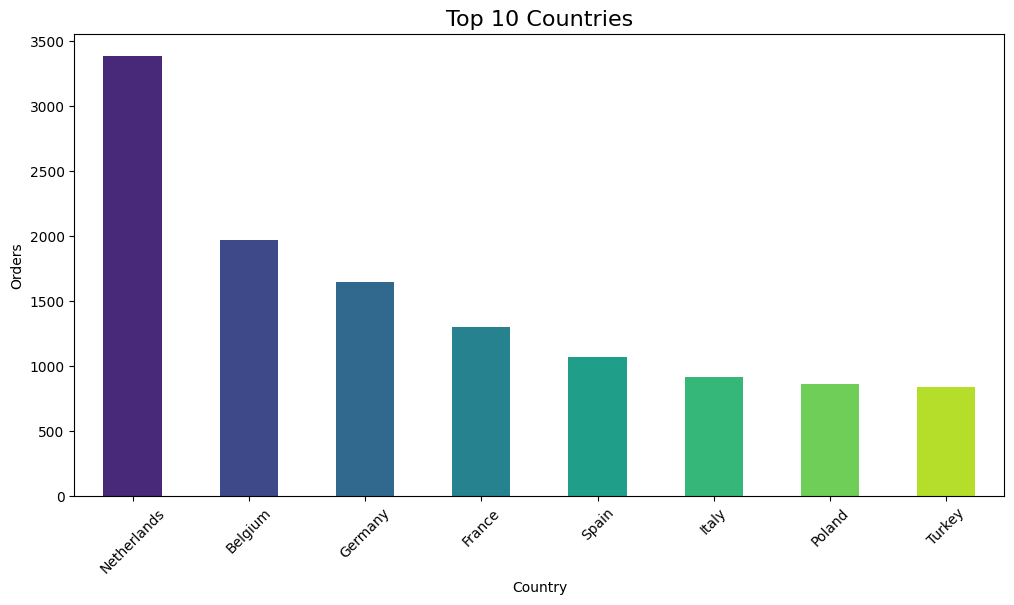

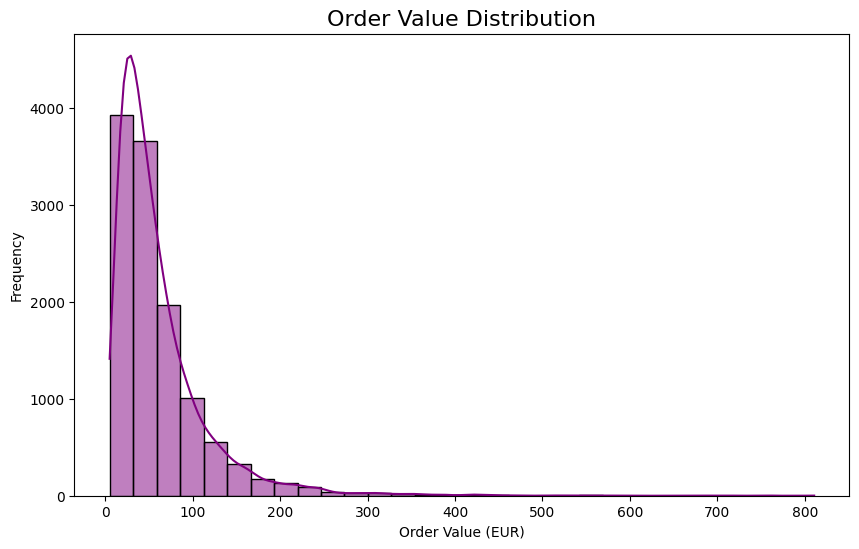

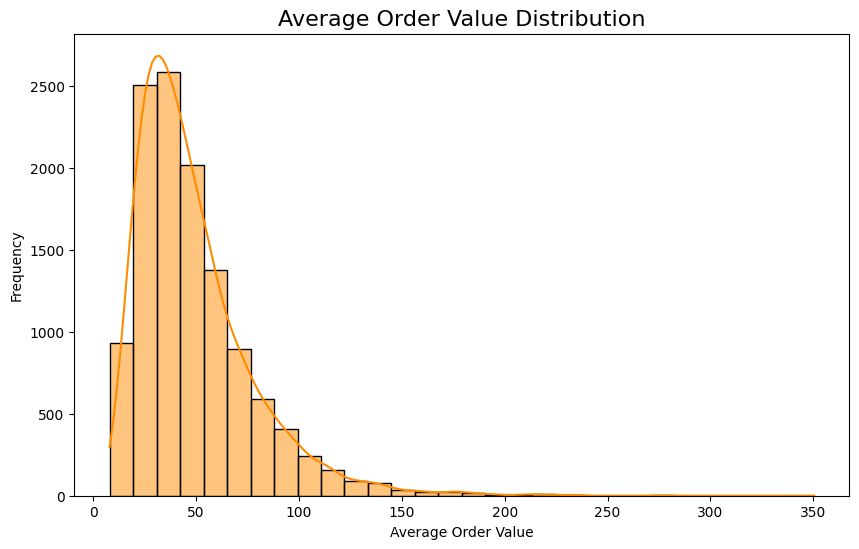

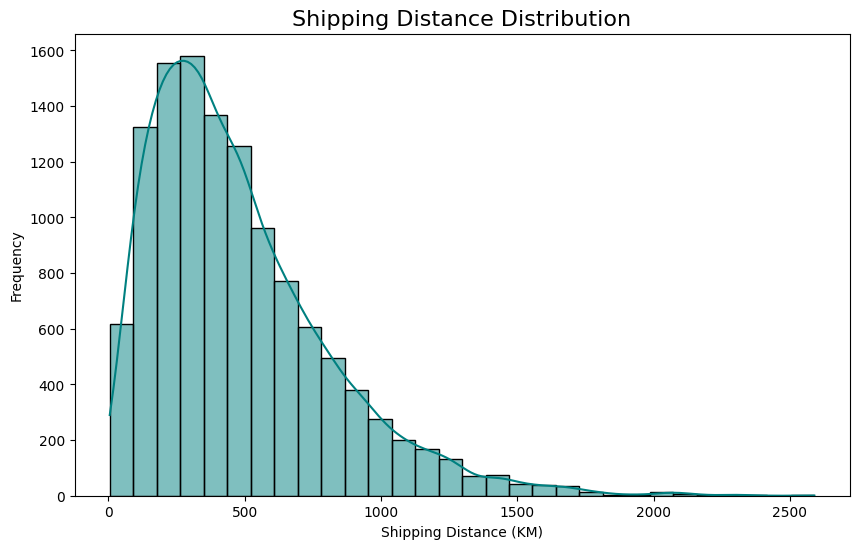

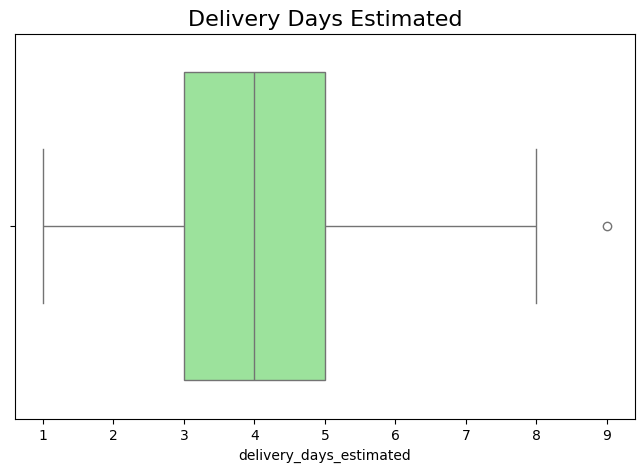

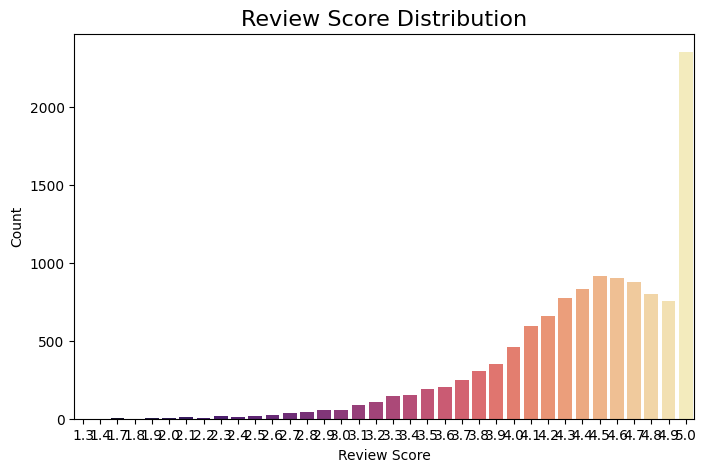

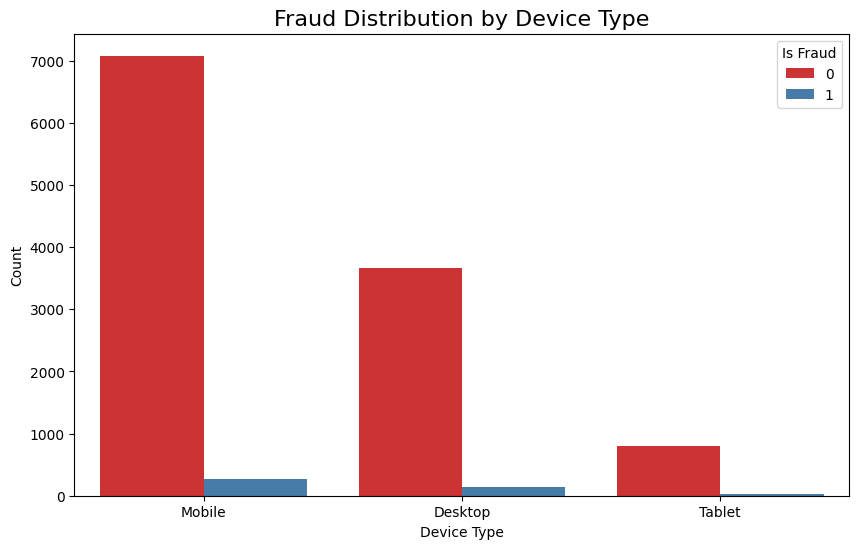

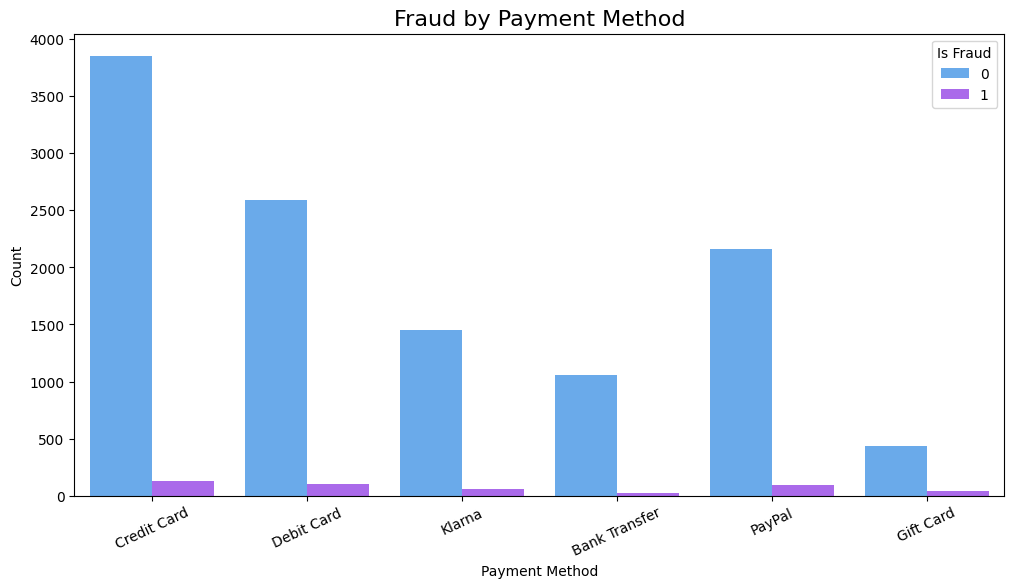

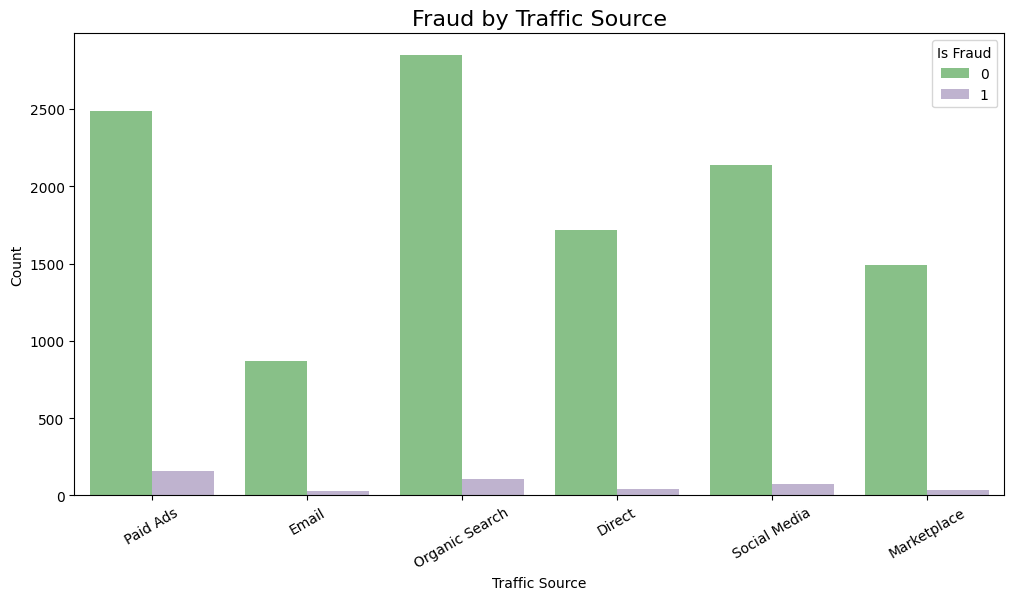

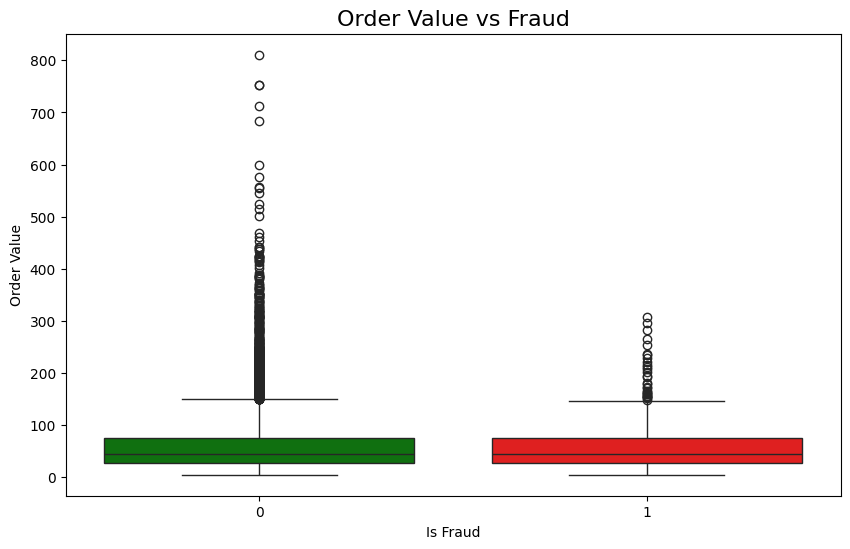

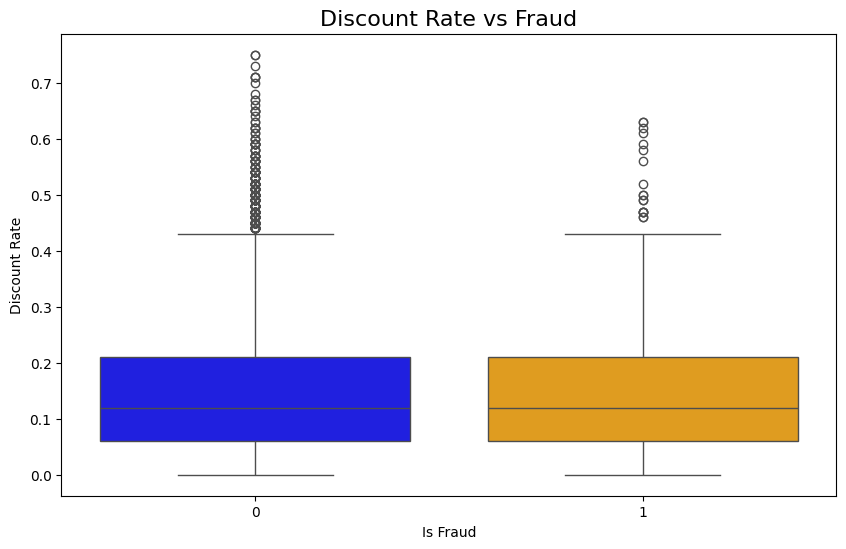

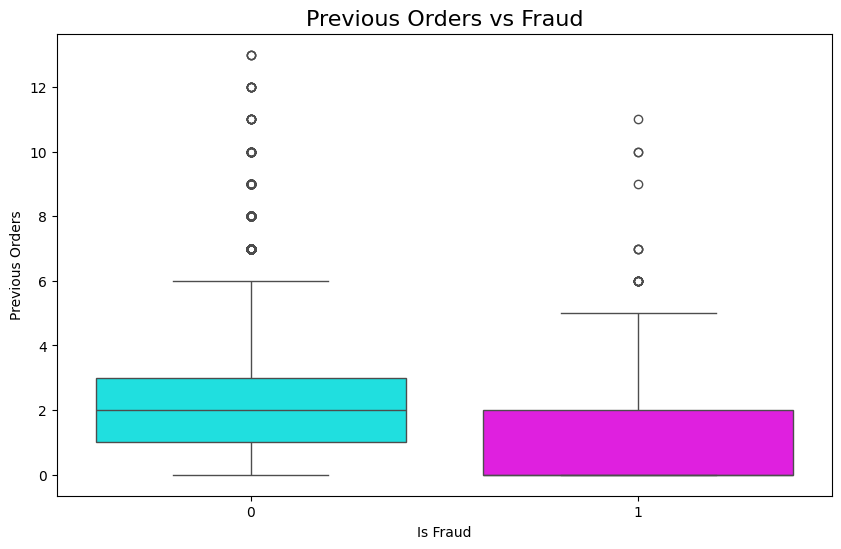

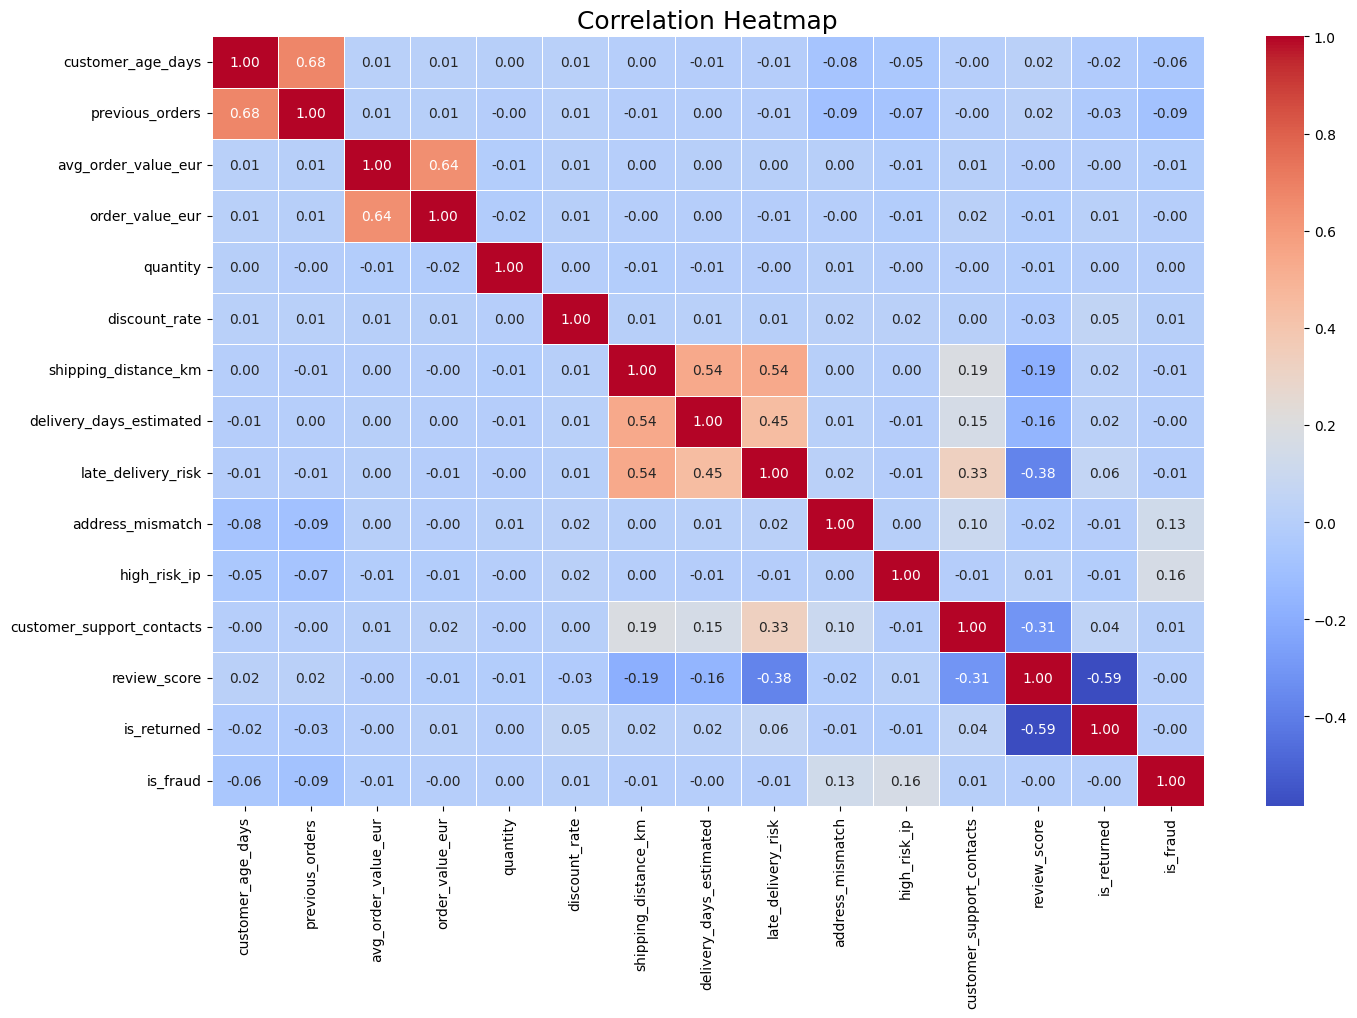

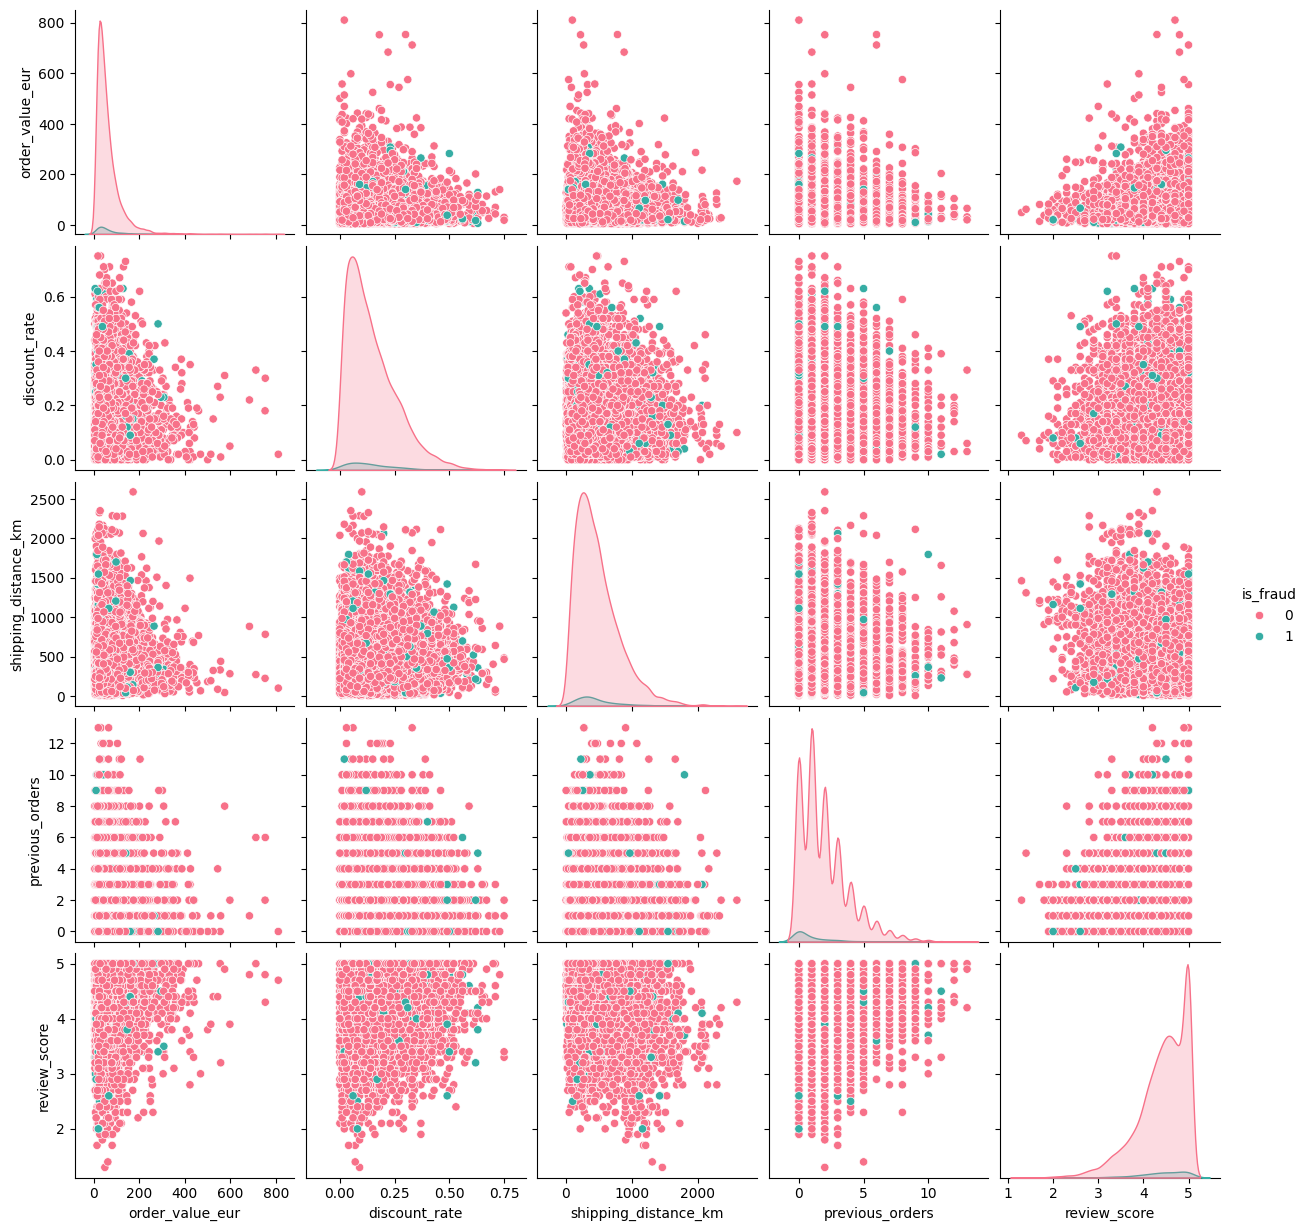

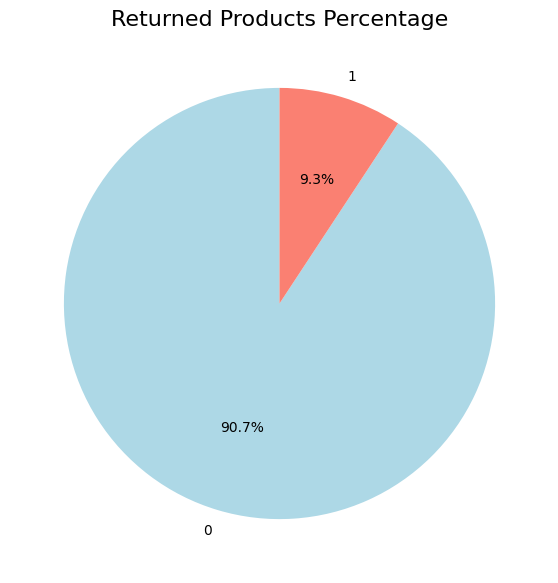

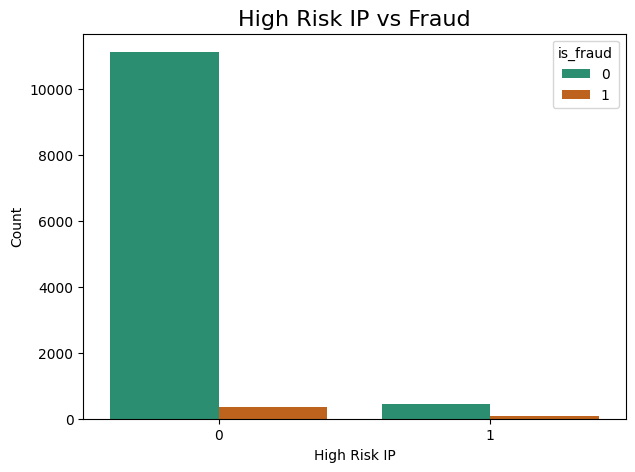

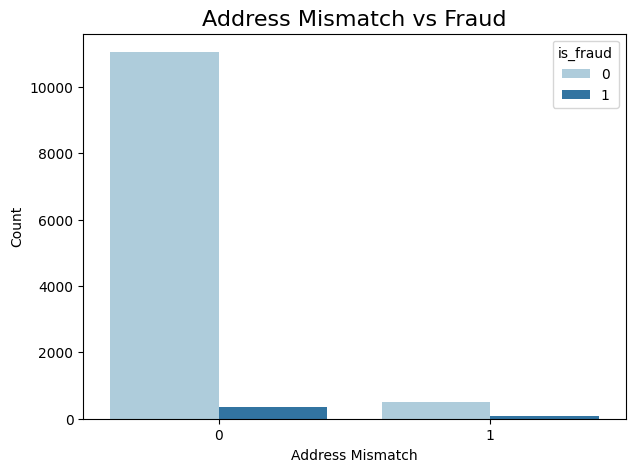

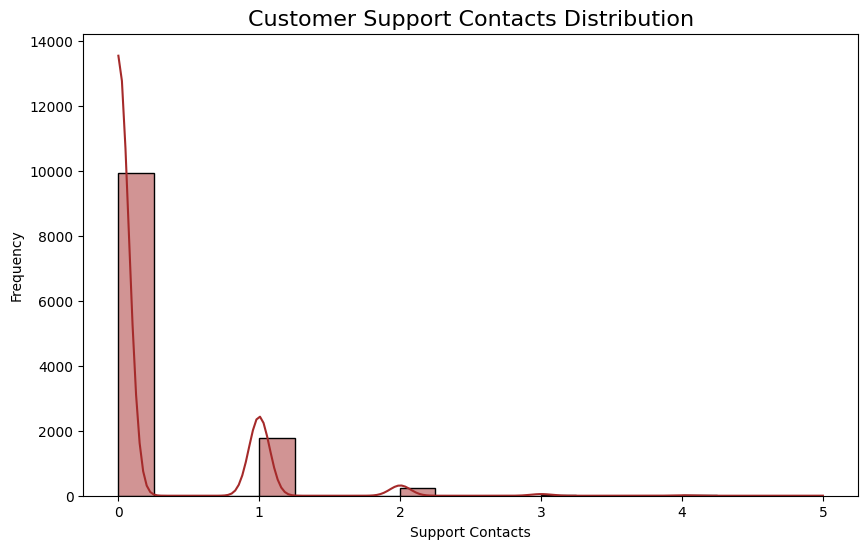

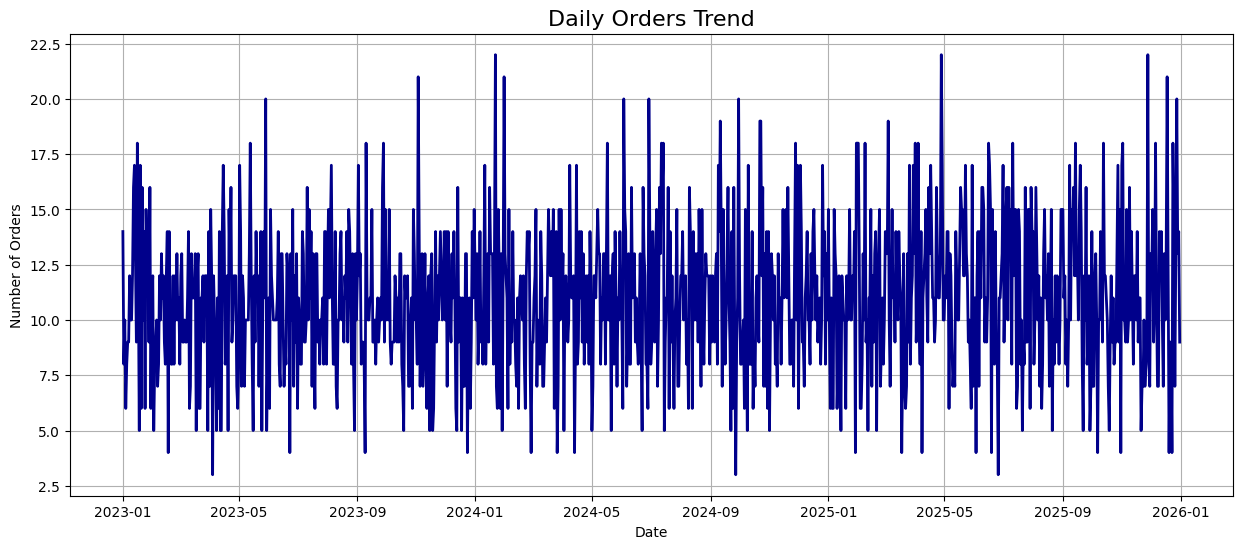

In [13]:
# =========================================================
# 1. TARGET VARIABLE DISTRIBUTION
# =========================================================

plt.figure(figsize=(7,5))
colors = ['skyblue', 'orange']

sns.countplot(
    x='is_fraud',
    data=df,
    palette=colors
)

plt.title("Fraud vs Non-Fraud Transactions", fontsize=16)
plt.xlabel("Is Fraud")
plt.ylabel("Count")
plt.show()

# =========================================================
# 2. RISK LABEL DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

risk_colors = ['green', 'gold', 'red', 'purple', 'blue']

sns.countplot(
    x='risk_label',
    data=df,
    palette=risk_colors
)

plt.title("Risk Label Distribution", fontsize=16)
plt.xlabel("Risk Label")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

# =========================================================
# 3. DEVICE TYPE DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

device_colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFD700']

sns.countplot(
    x='device_type',
    data=df,
    palette=device_colors
)

plt.title("Device Type Usage", fontsize=16)
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.show()

# =========================================================
# 4. TRAFFIC SOURCE DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,5))

traffic_colors = sns.color_palette("Set2")

sns.countplot(
    x='traffic_source',
    data=df,
    palette=traffic_colors
)

plt.title("Traffic Source Distribution", fontsize=16)
plt.xlabel("Traffic Source")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

# =========================================================
# 5. PAYMENT METHOD DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,5))

payment_colors = sns.color_palette("coolwarm")

sns.countplot(
    x='payment_method',
    data=df,
    palette=payment_colors
)

plt.title("Payment Method Distribution", fontsize=16)
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

# =========================================================
# 6. PRODUCT CATEGORY DISTRIBUTION
# =========================================================

plt.figure(figsize=(12,5))

category_colors = sns.color_palette("husl")

sns.countplot(
    x='product_category',
    data=df,
    palette=category_colors
)

plt.title("Product Category Distribution", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# =========================================================
# 7. COUNTRY DISTRIBUTION
# =========================================================

top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_countries.plot(
    kind='bar',
    color=sns.color_palette("viridis", len(top_countries))
)

plt.title("Top 10 Countries", fontsize=16)
plt.xlabel("Country")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

# =========================================================
# 8. ORDER VALUE DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['order_value_eur'],
    bins=30,
    kde=True,
    color='purple'
)

plt.title("Order Value Distribution", fontsize=16)
plt.xlabel("Order Value (EUR)")
plt.ylabel("Frequency")
plt.show()

# =========================================================
# 9. AVG ORDER VALUE DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['avg_order_value_eur'],
    bins=30,
    kde=True,
    color='darkorange'
)

plt.title("Average Order Value Distribution", fontsize=16)
plt.xlabel("Average Order Value")
plt.ylabel("Frequency")
plt.show()

# =========================================================
# 10. SHIPPING DISTANCE DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['shipping_distance_km'],
    bins=30,
    kde=True,
    color='teal'
)

plt.title("Shipping Distance Distribution", fontsize=16)
plt.xlabel("Shipping Distance (KM)")
plt.ylabel("Frequency")
plt.show()

# =========================================================
# 11. DELIVERY DAYS DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['delivery_days_estimated'],
    color='lightgreen'
)

plt.title("Delivery Days Estimated", fontsize=16)
plt.show()

# =========================================================
# 12. REVIEW SCORE DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='review_score',
    data=df,
    palette='magma'
)

plt.title("Review Score Distribution", fontsize=16)
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

# =========================================================
# 13. FRAUD BY DEVICE TYPE
# =========================================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='device_type',
    hue='is_fraud',
    data=df,
    palette='Set1'
)

plt.title("Fraud Distribution by Device Type", fontsize=16)
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.legend(title='Is Fraud')
plt.show()

# =========================================================
# 14. FRAUD BY PAYMENT METHOD
# =========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    x='payment_method',
    hue='is_fraud',
    data=df,
    palette='cool'
)

plt.title("Fraud by Payment Method", fontsize=16)
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=25)
plt.legend(title='Is Fraud')
plt.show()

# =========================================================
# 15. FRAUD BY TRAFFIC SOURCE
# =========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    x='traffic_source',
    hue='is_fraud',
    data=df,
    palette='Accent'
)

plt.title("Fraud by Traffic Source", fontsize=16)
plt.xlabel("Traffic Source")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title='Is Fraud')
plt.show()

# =========================================================
# 16. ORDER VALUE VS FRAUD
# =========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='is_fraud',
    y='order_value_eur',
    data=df,
    palette=['green', 'red']
)

plt.title("Order Value vs Fraud", fontsize=16)
plt.xlabel("Is Fraud")
plt.ylabel("Order Value")
plt.show()

# =========================================================
# 17. DISCOUNT RATE VS FRAUD
# =========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='is_fraud',
    y='discount_rate',
    data=df,
    palette=['blue', 'orange']
)

plt.title("Discount Rate vs Fraud", fontsize=16)
plt.xlabel("Is Fraud")
plt.ylabel("Discount Rate")
plt.show()

# =========================================================
# 18. PREVIOUS ORDERS VS FRAUD
# =========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='is_fraud',
    y='previous_orders',
    data=df,
    palette=['cyan', 'magenta']
)

plt.title("Previous Orders vs Fraud", fontsize=16)
plt.xlabel("Is Fraud")
plt.ylabel("Previous Orders")
plt.show()

# =========================================================
# 19. HEATMAP CORRELATION
# =========================================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16,10))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=18)
plt.show()

# =========================================================
# 20. PAIRPLOT
# =========================================================

selected_cols = [
    'order_value_eur',
    'discount_rate',
    'shipping_distance_km',
    'previous_orders',
    'review_score',
    'is_fraud'
]

sns.pairplot(
    df[selected_cols],
    hue='is_fraud',
    palette='husl'
)

plt.show()

# =========================================================
# 21. PIE CHART - RETURNED PRODUCTS
# =========================================================

returned_counts = df['is_returned'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    returned_counts,
    labels=returned_counts.index,
    autopct='%1.1f%%',
    colors=['lightblue', 'salmon'],
    startangle=90
)

plt.title("Returned Products Percentage", fontsize=16)
plt.show()

# =========================================================
# 22. HIGH RISK IP ANALYSIS
# =========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    x='high_risk_ip',
    hue='is_fraud',
    data=df,
    palette='Dark2'
)

plt.title("High Risk IP vs Fraud", fontsize=16)
plt.xlabel("High Risk IP")
plt.ylabel("Count")
plt.show()

# =========================================================
# 23. ADDRESS MISMATCH ANALYSIS
# =========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    x='address_mismatch',
    hue='is_fraud',
    data=df,
    palette='Paired'
)

plt.title("Address Mismatch vs Fraud", fontsize=16)
plt.xlabel("Address Mismatch")
plt.ylabel("Count")
plt.show()

# =========================================================
# 24. CUSTOMER SUPPORT CONTACTS
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['customer_support_contacts'],
    bins=20,
    kde=True,
    color='brown'
)

plt.title("Customer Support Contacts Distribution", fontsize=16)
plt.xlabel("Support Contacts")
plt.ylabel("Frequency")
plt.show()

# =========================================================
# 25. TIME SERIES ORDER ANALYSIS
# =========================================================

df['order_date'] = pd.to_datetime(df['order_date'])

daily_orders = df.groupby(df['order_date'].dt.date).size()

plt.figure(figsize=(15,6))

daily_orders.plot(
    color='darkblue',
    linewidth=2
)

plt.title("Daily Orders Trend", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.show()


## Feature engineering

In [14]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)



Target Distribution
is_fraud
0    11553
1      447
Name: count, dtype: int64

Dropped Leakage Columns : ['order_id', 'risk_label']

Feature Shape : (12000, 23)
Target Shape : (12000,)

Categorical Columns
['country', 'device_type', 'traffic_source', 'payment_method', 'product_category']

Numerical Columns
['customer_age_days', 'previous_orders', 'avg_order_value_eur', 'order_value_eur', 'quantity', 'discount_rate', 'shipping_distance_km', 'delivery_days_estimated', 'late_delivery_risk', 'address_mismatch', 'high_risk_ip', 'customer_support_contacts', 'review_score', 'is_returned']

Train Shape : (9600, 23)
Test Shape : (2400, 23)


MODEL : Logistic Regression

Accuracy  : 0.9629
Precision : 0.5000
Recall    : 0.0112
F1 Score  : 0.0220
ROC AUC   : 0.7713

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2311
           1       0.50      0.01      0.02        89

    accuracy                           0.96     

<Figure size 1200x800 with 0 Axes>

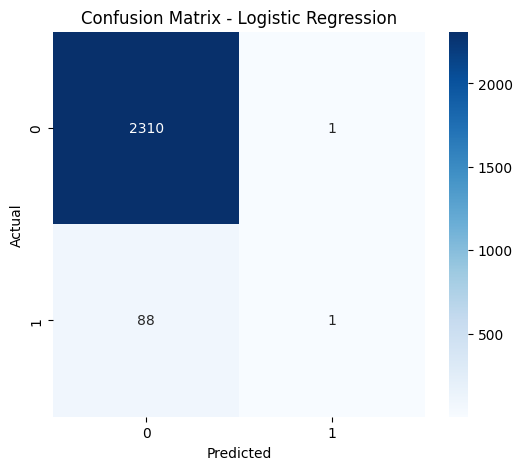



MODEL : Decision Tree

Accuracy  : 0.9525
Precision : 0.1622
Recall    : 0.0674
F1 Score  : 0.0952
ROC AUC   : 0.6113

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      2311
           1       0.16      0.07      0.10        89

    accuracy                           0.95      2400
   macro avg       0.56      0.53      0.54      2400
weighted avg       0.94      0.95      0.94      2400



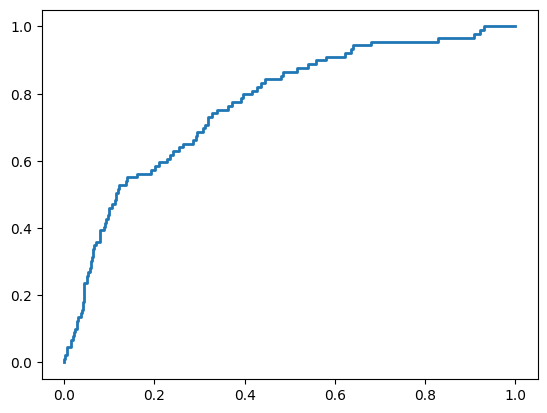

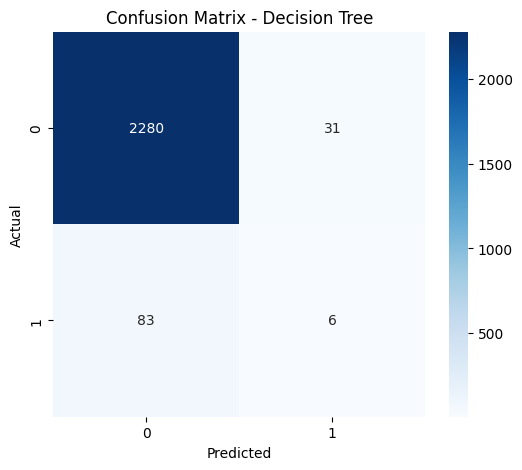



MODEL : Random Forest

Accuracy  : 0.9629
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
ROC AUC   : 0.7550

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2311
           1       0.00      0.00      0.00        89

    accuracy                           0.96      2400
   macro avg       0.48      0.50      0.49      2400
weighted avg       0.93      0.96      0.94      2400



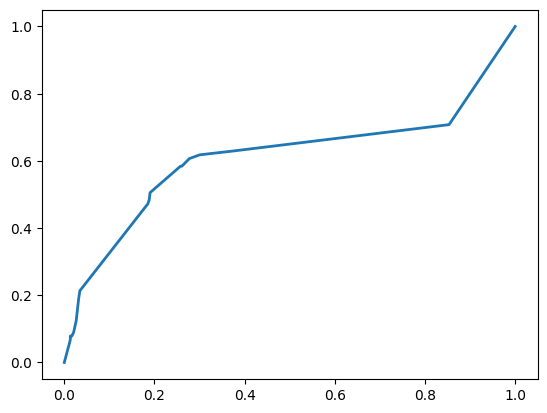

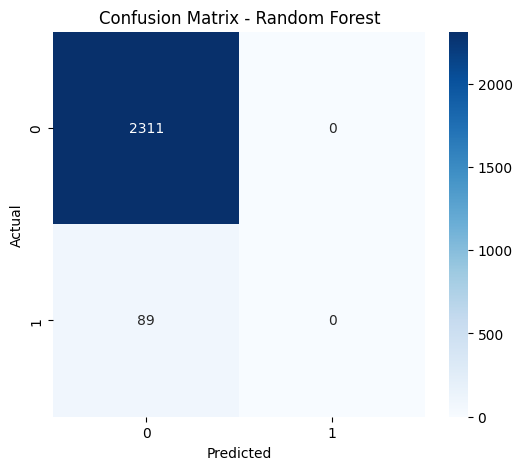



MODEL : Gradient Boosting

Accuracy  : 0.9617
Precision : 0.2000
Recall    : 0.0112
F1 Score  : 0.0213
ROC AUC   : 0.7836

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2311
           1       0.20      0.01      0.02        89

    accuracy                           0.96      2400
   macro avg       0.58      0.50      0.50      2400
weighted avg       0.93      0.96      0.94      2400



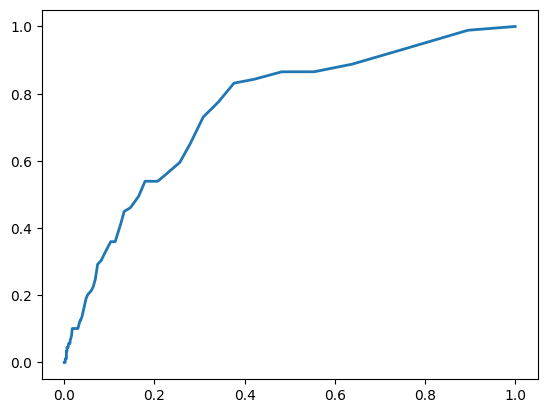

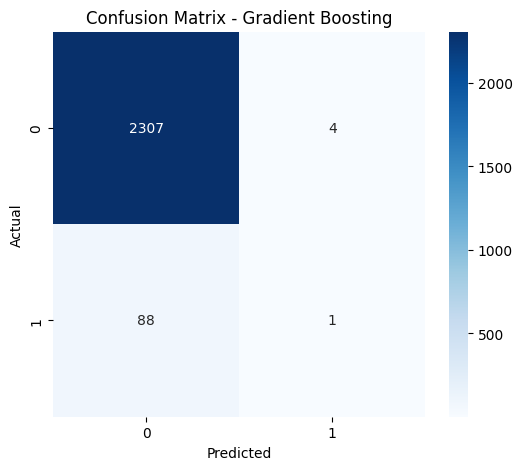



MODEL : AdaBoost

Accuracy  : 0.9629
Precision : 0.5000
Recall    : 0.0225
F1 Score  : 0.0430
ROC AUC   : 0.7929

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2311
           1       0.50      0.02      0.04        89

    accuracy                           0.96      2400
   macro avg       0.73      0.51      0.51      2400
weighted avg       0.95      0.96      0.95      2400



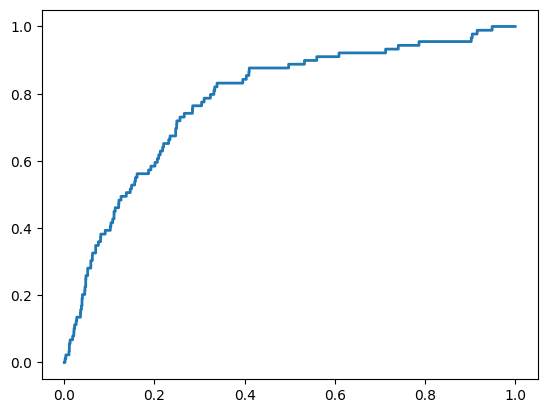

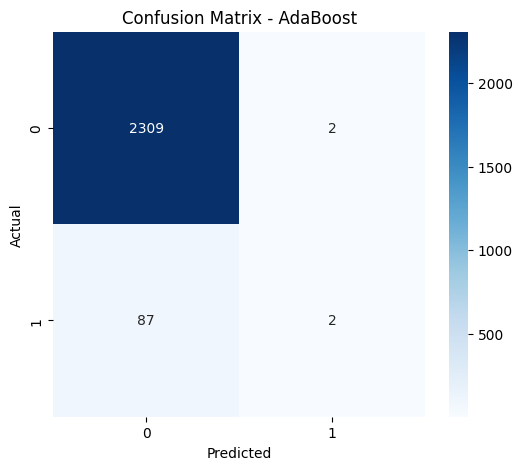



MODEL : Support Vector Machine

Accuracy  : 0.9629
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
ROC AUC   : 0.5935

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2311
           1       0.00      0.00      0.00        89

    accuracy                           0.96      2400
   macro avg       0.48      0.50      0.49      2400
weighted avg       0.93      0.96      0.94      2400



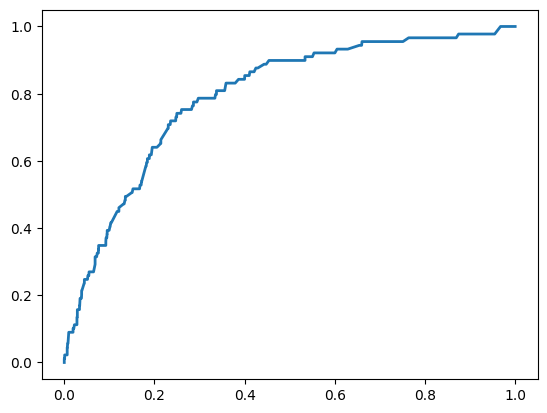

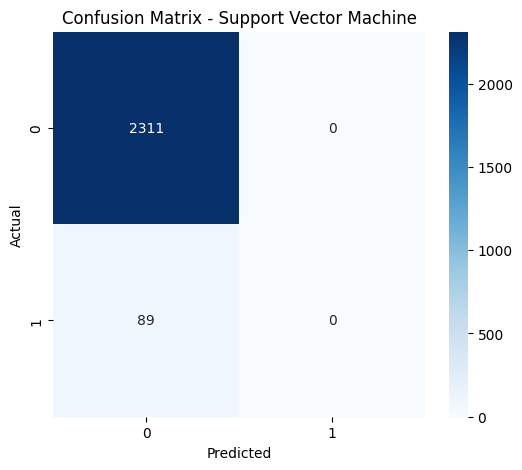



MODEL : K-Nearest Neighbors

Accuracy  : 0.9600
Precision : 0.1818
Recall    : 0.0225
F1 Score  : 0.0400
ROC AUC   : 0.5893

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2311
           1       0.18      0.02      0.04        89

    accuracy                           0.96      2400
   macro avg       0.57      0.51      0.51      2400
weighted avg       0.93      0.96      0.94      2400



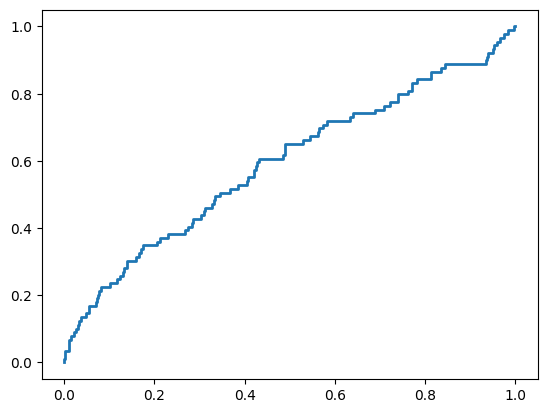

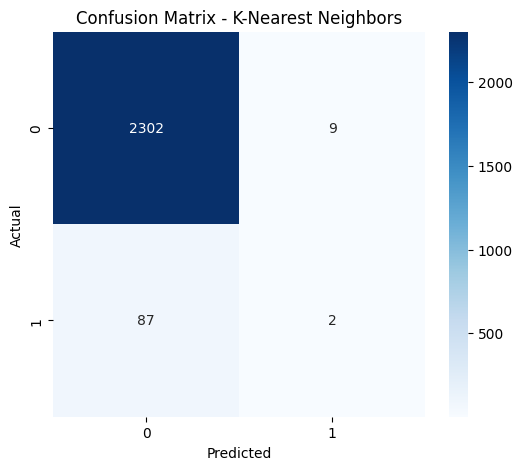



MODEL : Naive Bayes

Accuracy  : 0.8883
Precision : 0.1377
Recall    : 0.3820
F1 Score  : 0.2024
ROC AUC   : 0.7224

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      2311
           1       0.14      0.38      0.20        89

    accuracy                           0.89      2400
   macro avg       0.56      0.64      0.57      2400
weighted avg       0.94      0.89      0.91      2400



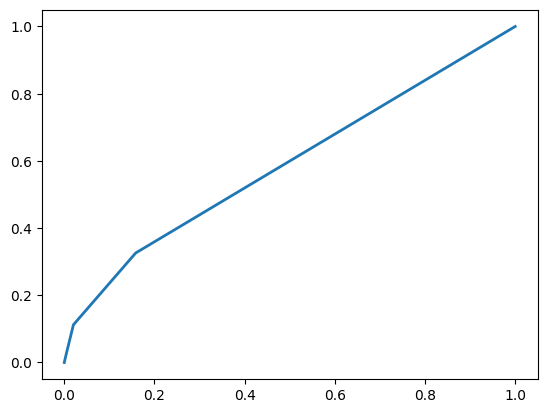

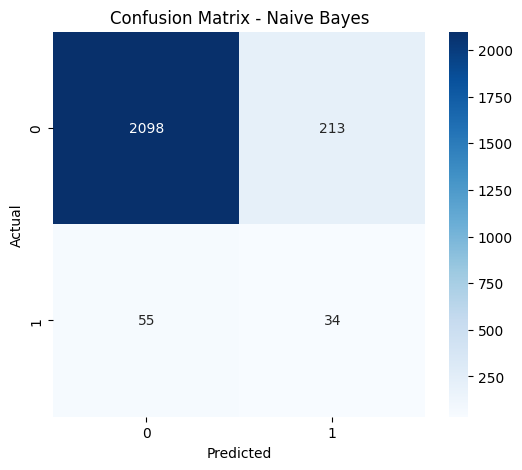

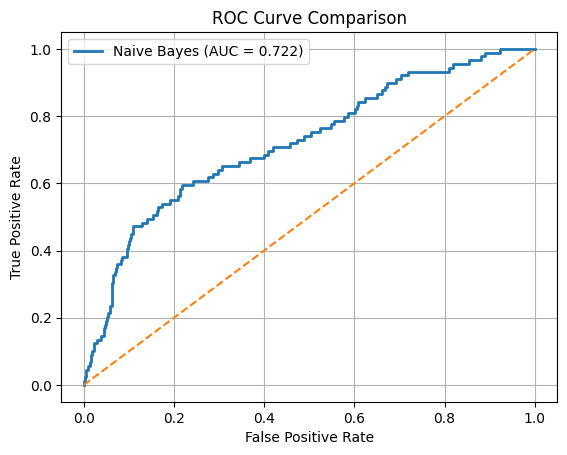



FINAL MODEL COMPARISON
                    Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
4                AdaBoost  0.962917   0.500000  0.022472  0.043011  0.792927
3       Gradient Boosting  0.961667   0.200000  0.011236  0.021277  0.783568
0     Logistic Regression  0.962917   0.500000  0.011236  0.021978  0.771304
2           Random Forest  0.962917   0.000000  0.000000  0.000000  0.754951
7             Naive Bayes  0.888333   0.137652  0.382022  0.202381  0.722388
1           Decision Tree  0.952500   0.162162  0.067416  0.095238  0.611256
5  Support Vector Machine  0.962917   0.000000  0.000000  0.000000  0.593454
6     K-Nearest Neighbors  0.960000   0.181818  0.022472  0.040000  0.589329


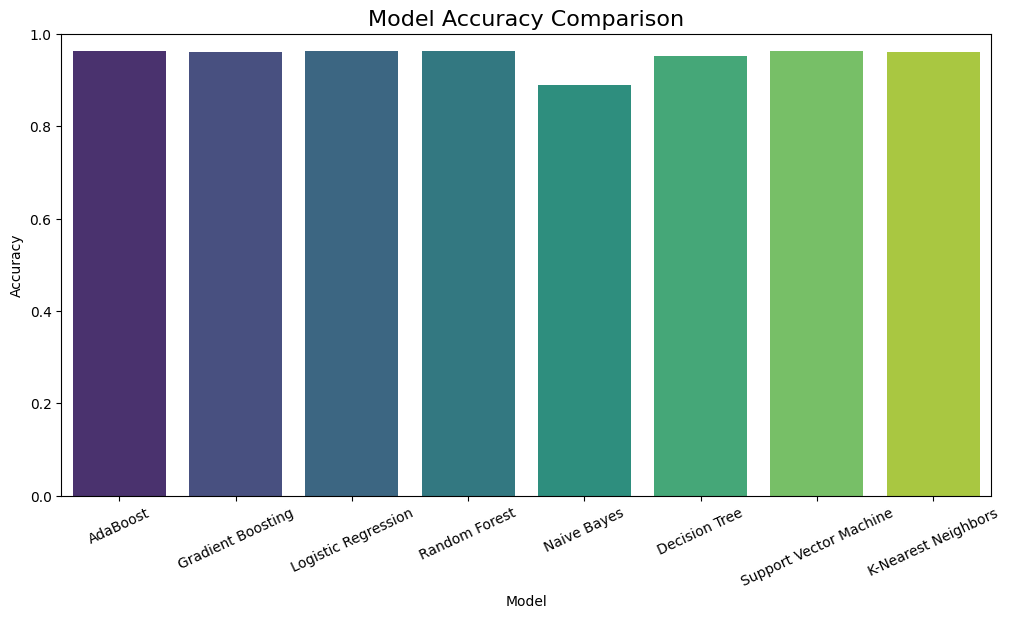

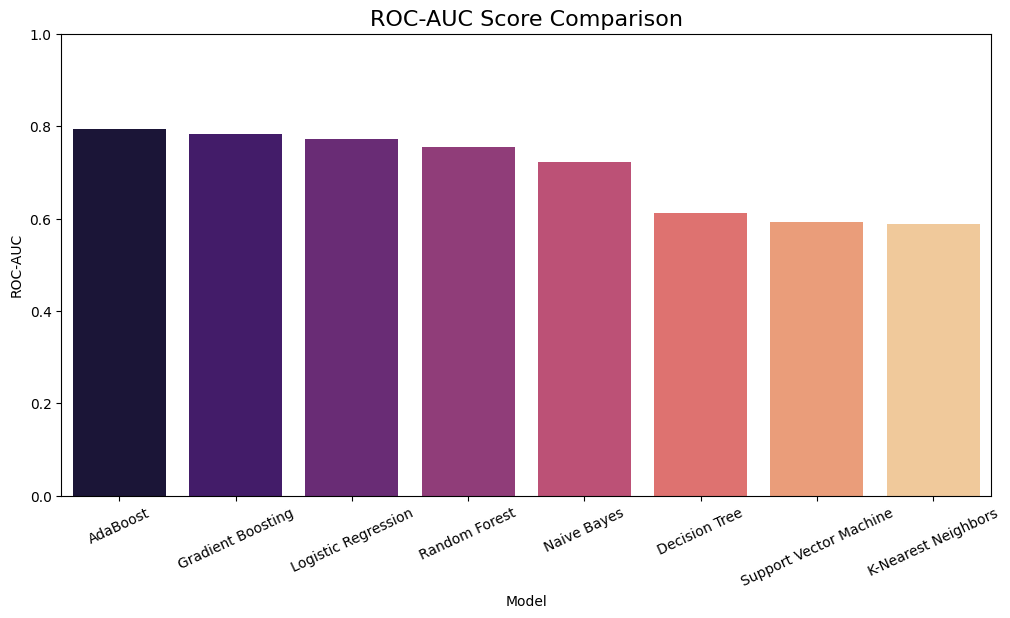



BEST MODEL

Best Model : AdaBoost
Accuracy   : 0.9629
ROC-AUC    : 0.7929


FEATURE IMPORTANCE - RANDOM FOREST


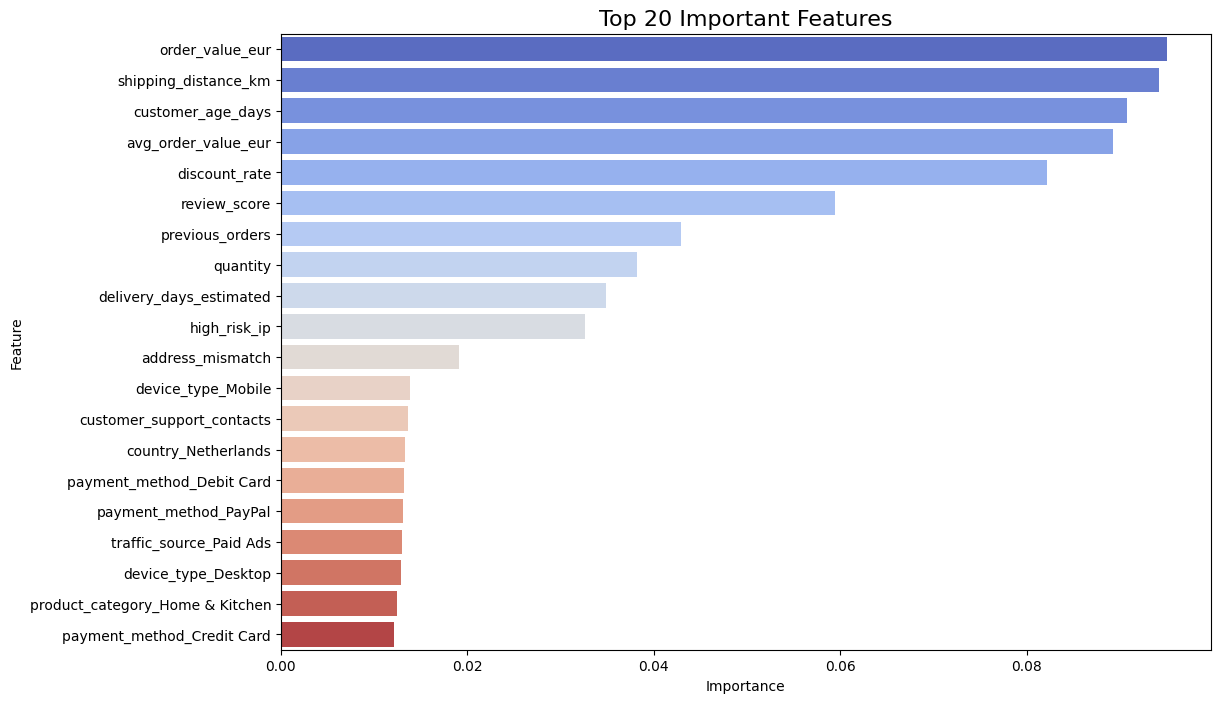



ML PIPELINE COMPLETED SUCCESSFULLY


In [15]:
print("\nTarget Distribution")
print(df['is_fraud'].value_counts())

# =========================================================
# DROP DATA LEAKAGE COLUMNS
# =========================================================

# IMPORTANT:
# risk_label may directly depend on fraud
# order_id is unique identifier
# remove leakage columns

drop_cols = ['order_id', 'risk_label']

df = df.drop(columns=drop_cols)

print("\nDropped Leakage Columns :", drop_cols)

# =========================================================
# CONVERT DATE COLUMN
# =========================================================

df['order_date'] = pd.to_datetime(df['order_date'])

# Extract useful date features
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_day'] = df['order_date'].dt.day
df['order_weekday'] = df['order_date'].dt.weekday

# Remove original date column
df.drop(columns=['order_date'], inplace=True)

# =========================================================
# DEFINE FEATURES AND TARGET
# =========================================================

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

print("\nFeature Shape :", X.shape)
print("Target Shape :", y.shape)

# =========================================================
# IDENTIFY COLUMN TYPES
# =========================================================

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("\nCategorical Columns")
print(categorical_cols)

print("\nNumerical Columns")
print(numerical_cols)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain Shape :", X_train.shape)
print("Test Shape :", X_test.shape)

# =========================================================
# PREPROCESSING PIPELINE
# =========================================================

# Numerical pipeline
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Categorical pipeline
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# =========================================================
# MACHINE LEARNING MODELS
# =========================================================

models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Support Vector Machine": SVC(
        probability=True
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB()
}

# =========================================================
# STORE RESULTS
# =========================================================

results = []

# =========================================================
# ROC CURVE PLOT
# =========================================================

plt.figure(figsize=(12,8))

# =========================================================
# TRAIN & EVALUATE EACH MODEL
# =========================================================

for model_name, model in models.items():

    print("\n")
    print("="*70)
    print(f"MODEL : {model_name}")
    print("="*70)

    # =====================================================
    # CREATE PIPELINE
    # =====================================================

    if model_name == "Naive Bayes":

        # Need dense matrix for GaussianNB
        pipeline = Pipeline(
            steps=[
                ('preprocessor', preprocessor),
                ('classifier', model)
            ]
        )

    else:

        pipeline = Pipeline(
            steps=[
                ('preprocessor', preprocessor),
                ('classifier', model)
            ]
        )

    # =====================================================
    # TRAIN MODEL
    # =====================================================

    pipeline.fit(X_train, y_train)

    # =====================================================
    # PREDICTIONS
    # =====================================================

    y_pred = pipeline.predict(X_test)

    # Probability prediction for ROC
    y_prob = pipeline.predict_proba(X_test)[:,1]

    # =====================================================
    # EVALUATION METRICS
    # =====================================================

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    # =====================================================
    # STORE RESULTS
    # =====================================================

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    })

    # =====================================================
    # PRINT METRICS
    # =====================================================

    print(f"\nAccuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    # =====================================================
    # ROC CURVE
    # =====================================================

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{model_name} (AUC = {roc_auc:.3f})'
    )

# =========================================================
# FINAL ROC CURVE
# =========================================================

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# RESULTS DATAFRAME
# =========================================================

results_df = pd.DataFrame(results)

# Sort by ROC-AUC
results_df = results_df.sort_values(
    by='ROC-AUC',
    ascending=False
)

print("\n")
print("="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

print(results_df)

# =========================================================
# VISUALIZE MODEL ACCURACY
# =========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df,
    palette='viridis'
)

plt.title("Model Accuracy Comparison", fontsize=16)

plt.xticks(rotation=25)

plt.ylim(0,1)

plt.show()

# =========================================================
# VISUALIZE ROC-AUC
# =========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='ROC-AUC',
    data=results_df,
    palette='magma'
)

plt.title("ROC-AUC Score Comparison", fontsize=16)

plt.xticks(rotation=25)

plt.ylim(0,1)

plt.show()

# =========================================================
# BEST MODEL
# =========================================================

best_model = results_df.iloc[0]

print("\n")
print("="*60)
print("BEST MODEL")
print("="*60)

print(f"\nBest Model : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"ROC-AUC    : {best_model['ROC-AUC']:.4f}")

# =========================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# =========================================================

print("\n")
print("="*60)
print("FEATURE IMPORTANCE - RANDOM FOREST")
print("="*60)

# Train Random Forest separately
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

# Get transformed feature names
cat_features = rf_pipeline.named_steps[
    'preprocessor'
].named_transformers_[
    'cat'
].named_steps[
    'encoder'
].get_feature_names_out(categorical_cols)

all_features = numerical_cols + list(cat_features)

# Feature importances
importances = rf_pipeline.named_steps[
    'classifier'
].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(20)

# =========================================================
# PLOT FEATURE IMPORTANCE
# =========================================================

plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='coolwarm'
)

plt.title("Top 20 Important Features", fontsize=16)

plt.show()

# =========================================================
# COMPLETED
# =========================================================

print("\n")
print("="*60)
print("ML PIPELINE COMPLETED SUCCESSFULLY")
print("="*60)

## Thank you...pls upvote!!!!!!!!!!!!